In [9]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
!ls "/content/drive/MyDrive/yolov5"

In [23]:
!git clone https://github.com/ultralytics/yolov5
# %cd yolov5
!pip install -r requirements.txt


Cloning into 'yolov5'...
remote: Enumerating objects: 17413, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 17413 (delta 64), reused 22 (delta 22), pack-reused 17327 (from 4)
Receiving objects: 100% (17413/17413), 16.29 MiB | 26.87 MiB/s, done.
Resolving deltas: 100% (11929/11929), done.
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [24]:
%cd yolov5


/content/yolov5


In [25]:
!pip install -r requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [26]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 121.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [28]:
from roboflow import Roboflow
rf = Roboflow(api_key="CQWZcs9M1qDRCWjCoQZs")  # api key
project = rf.workspace("viad-optics-senior-design").project("senior-design-viad")
version = project.version(5)
dataset = version.download("yolov5")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Senior-Design-VIAD-5 in yolov5pytorch:: 100%|██████████| 74846/74846 [00:11<00:00, 6402.73it/s]


In [29]:
!ls /content/yolov5/Senior-Design-VIAD-5/

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [31]:
import os
os.environ["WANDB_MODE"] = "disabled"


In [32]:
!python /content/yolov5/train.py \
--img 640 \
--batch 8 \
--epochs 5 \
--data /content/yolov5/Senior-Design-VIAD-5/data.yaml \
--weights yolov5s.pt \
--cache

Streaming output truncated to the last 5000 lines.
  with torch.cuda.amp.autocast(amp):
        4/4      2.41G    0.04548    0.02305    0.02273         20        640:  37% 1440/3923 [05:12<10:40,  3.88it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
        4/4      2.41G    0.04548    0.02305    0.02273         28        640:  37% 1441/3923 [05:12<11:16,  3.67it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
        4/4      2.41G    0.04548    0.02305    0.02272         21        640:  37% 1442/3923 [05:13<11:01,  3.75it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.aut

In [36]:
import pandas as pd

df = pd.read_csv('/content/yolov5/runs/train/exp/results.csv')
print(df.columns.tolist())

import pandas as pd
import matplotlib.pyplot as plt

# Load CSV and strip column names
df = pd.read_csv('/content/yolov5/runs/train/exp/results.csv')

df.columns = [col.strip() for col in df.columns]  # remove leading/trailing spaces

# Define metrics to plot
metrics = [
    'train/box_loss', 'train/obj_loss', 'train/cls_loss',
    'metrics/precision', 'metrics/recall',
    'metrics/mAP_0.5', 'metrics/mAP_0.5:0.95'
]

['               epoch', '      train/box_loss', '      train/obj_loss', '      train/cls_loss', '   metrics/precision', '      metrics/recall', '     metrics/mAP_0.5', 'metrics/mAP_0.5:0.95', '        val/box_loss', '        val/obj_loss', '        val/cls_loss', '               x/lr0', '               x/lr1', '               x/lr2']


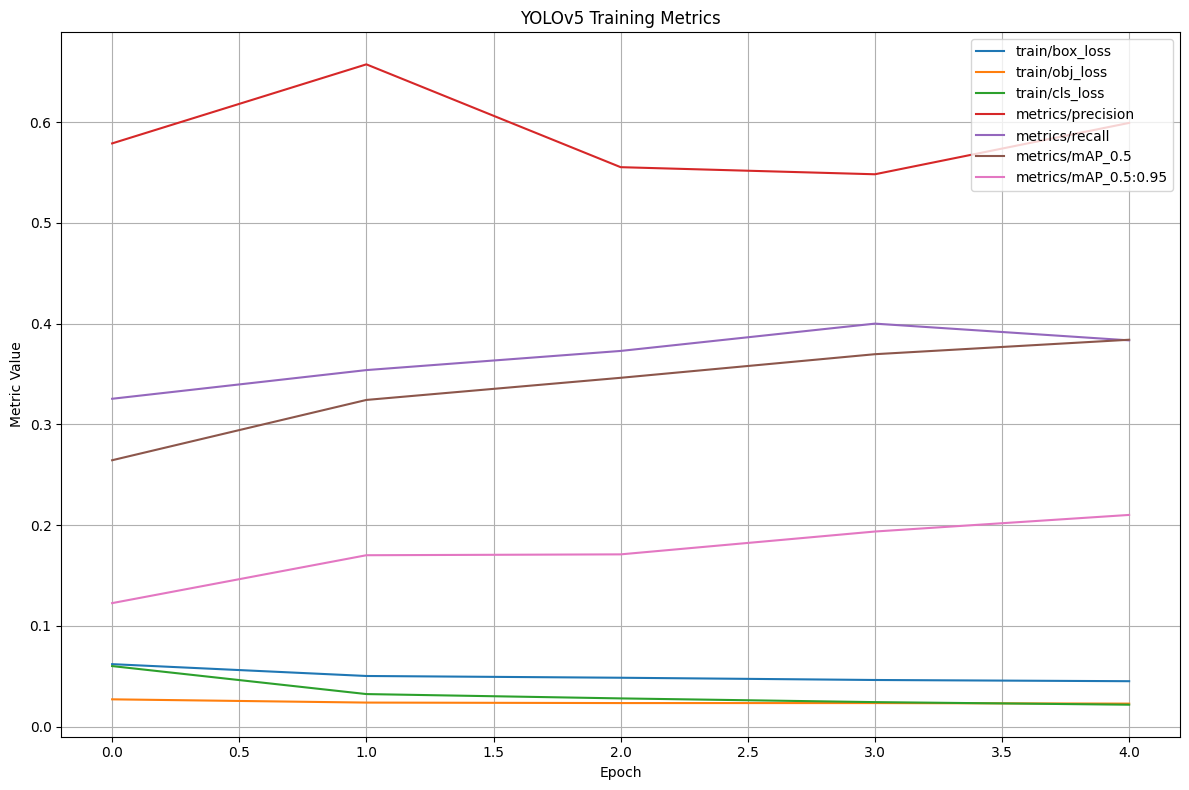

<Figure size 640x480 with 0 Axes>

In [37]:
plt.figure(figsize=(12, 8))
for metric in metrics:
    plt.plot(df['epoch'], df[metric], label=metric)

plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('YOLOv5 Training Metrics')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.savefig('/content/yolov5/runs/train/exp/results.png')
